# Active Ising model

**References**:

[1] A. P. Solon and J. Tailleur, Revisiting the Flocking Transition Using Active Spins, Phys. Rev. Lett. 111, 078101 (2013).

[2] A. P. Solon and J. Tailleur, Flocking with discrete symmetry: The two-dimensional active Ising model, Phys. Rev. E 92, 042119 (2015).



## Setup

In [ ]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', 'simulation'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # for phase plot
import json
from aim_core import compute_h_J_phase, get_profiles_multi_sim, compute_eta_first_principles, compute_eta_inferential

# Plot setting
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'cmr10'  # Use the Computer Modern Roman font
plt.rcParams['mathtext.fontset'] = 'cm'  # Use Computer Modern for math text
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.labelsize'] = 14  # Axis labels
plt.rcParams['axes.titlesize'] = 18  # Title
plt.rcParams['xtick.labelsize'] = 14 # X tick labels
plt.rcParams['ytick.labelsize'] = 14 # Y tick labels
plt.rcParams['legend.fontsize'] = 12  # Legend

COLORS = ["#B2182B","#EFB9A2","#4D4D4D","#92C5DE","#2166AC"]
RED = "#B73B39"
BLUE = "#0065A8"
GREEN = "#7ea364"
phase_colors = [COLORS[0], COLORS[1], COLORS[3], COLORS[4]]

In [2]:
# simulations
data = np.load('../data/aim_ness_100x100_h0.000.npz')
Lx, Ly = data['Lx'], data['Ly']
rho0, beta, epsilon = data['rho0'], data['beta'], data['epsilon']
J_list = data['J_list']
entropies = data['entropies']
energies = data['energies']
E_Js = data['E_Js']
E_hs = data['E_hs']
mean_rho_x = data['mean_rho_x']
mean_m_x = data['mean_m_x']
final_rho_x = data['final_rho_x']
final_m_x = data['final_m_x']

# load various h data
data_h025 = np.load('../data/aim_ness_100x100_h0.025.npz')
data_h050 = np.load('../data/aim_ness_100x100_h0.050.npz')
data_h075 = np.load('../data/aim_ness_100x100_h0.075.npz')
data_h100 = np.load('../data/aim_ness_100x100_h0.100.npz')
data_h200 = np.load('../data/aim_ness_100x100_h0.200.npz')
data_h300 = np.load('../data/aim_ness_100x100_h0.300.npz')

# eta epsilon=1.0, h=0.0
eta,_,_ = compute_eta_first_principles(data)
etaInf,_,_ = compute_eta_inferential(data)
max_eta = np.max(eta[1:])
max_etaInf = np.max(etaInf[1:])

# eta vs etaInfo plot (h varies)
eta_h025,_,_ = compute_eta_first_principles(data_h025)
etaInf_h025,_,_ = compute_eta_inferential(data_h025)
eta_h050,_,_ = compute_eta_first_principles(data_h050)
etaInf_h050,_,_ = compute_eta_inferential(data_h050)
eta_h075,_,_ = compute_eta_first_principles(data_h075)
etaInf_h075,_,_ = compute_eta_inferential(data_h075)
eta_h100,_,_ = compute_eta_first_principles(data_h100)
etaInf_h100,_,_ = compute_eta_inferential(data_h100)
eta_h200,_,_ = compute_eta_first_principles(data_h200)
etaInf_h200,_,_ = compute_eta_inferential(data_h200)
eta_h300,_,_ = compute_eta_first_principles(data_h300)
etaInf_h300,_,_ = compute_eta_inferential(data_h300)

# max eta and etaInf
max_etaInf_h300 = np.max(etaInf_h300[1:])
max_eta_h300 = np.max(eta_h300[1:])
max_etaInf_h200 = np.max(etaInf_h200[1:])
max_eta_h200 = np.max(eta_h200[1:])
max_etaInf_h100 = np.max(etaInf_h100[1:])
max_eta_h100 = np.max(eta_h100[1:])
max_etaInf_h075 = np.max(etaInf_h075[1:])
max_eta_h075 = np.max(eta_h075[1:])
max_etaInf_h050 = np.max(etaInf_h050[1:])
max_eta_h050 = np.max(eta_h050[1:])
max_etaInf_h025 = np.max(etaInf_h025[1:])
max_eta_h025 = np.max(eta_h025[1:])

## Phase plot

In [ ]:
# Compute h-J phase plot using compute_h_J_phase function
hs = np.linspace(-0.3, 0.3, 251)
Js = np.linspace(0.5, 2.65, 251)
alpha_m = 1.0
rho0 = 3.0
epsilon = 1.0
D = 1.0
phase = compute_h_J_phase(hs, Js, alpha_m, rho0, epsilon, D)

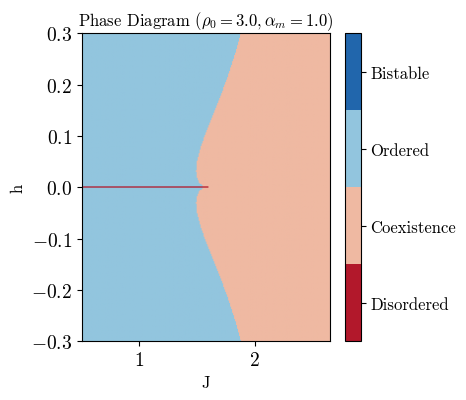

In [3]:
# or load data if already computed
with open('../data/aim_phase.json', 'r') as f:
    phasedata = json.load(f) 
hs = np.array(phasedata['hs'])
Js = np.array(phasedata['Js'])
phase = np.array(phasedata['phase'])
rho0 = phasedata['rho0']
alpha_m = phasedata['alpha_m']

plt.figure(figsize=(4, 4))
cmap=mcolors.ListedColormap(phase_colors)
plt.imshow(phase, origin='lower', extent=(Js[0], Js[-1], hs[0], hs[-1]), aspect='auto', cmap=cmap, alpha=1, vmin=0, vmax=3)
cbar = plt.colorbar(ticks=[0.375, 1.125, 1.875, 2.625]);
cbar.set_ticklabels(['Disordered', 'Coexistence', 'Ordered', 'Bistable'], fontsize=12)
plt.xlabel('J', fontsize=12)
plt.ylabel('h', fontsize=12)
plt.title(rf'Phase Diagram ($\rho_0 = {rho0}, \alpha_m = {alpha_m}$)', fontsize=12);

## Profile

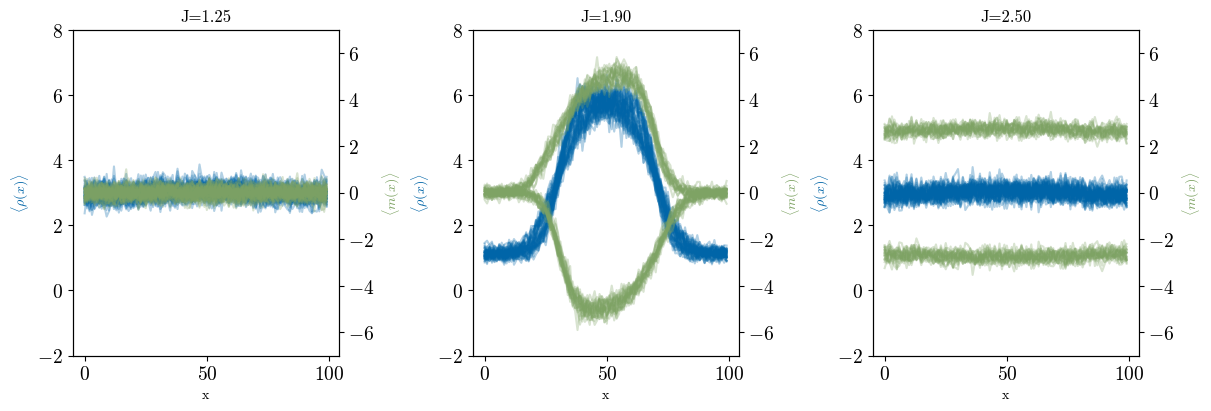

In [5]:
# plot profile
Js_to_plot = [1.25, 1.9, 2.5]
J_idxs = [np.argmin(np.abs(J_list - J)) for J in Js_to_plot]
rho_x_multi, m_x_multi = get_profiles_multi_sim(data, idxs=J_idxs)

# plot profiles for the three J values
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for i, J in enumerate(Js_to_plot):
    ax_rho = ax[i]
    ax_m = ax_rho.twinx()
    for sim_idx in range(rho_x_multi.shape[1]):
        ax_rho.plot(range(Lx), rho_x_multi[i, sim_idx], color=BLUE, alpha=0.3)
        ax_m.plot(range(Lx), m_x_multi[i, sim_idx], color=GREEN, alpha=0.3)
    
    ax_rho.set_title(f'J={Js_to_plot[i]:.2f}', fontsize=12)
    ax_rho.set_xlabel('x', fontsize=10)
    ax_rho.set_ylabel(r'$\langle \rho(x) \rangle$', color=BLUE, fontsize=10)
    ax_rho.set_ylim(-2, 8)
    ax_m.set_ylim(-7, 7)
    ax_m.set_ylabel(r'$\langle m(x) \rangle$', color=GREEN, fontsize=10)

## Efficiencies

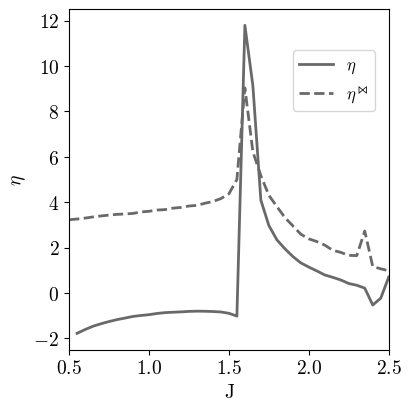

In [ ]:
# plot eta vs J
plt.figure(figsize=(4,4), constrained_layout=True)

# Plot eta and etaInf
plt.plot(J_list[1:], eta, label=r'$\eta$',color='dimgrey', lw=2)
plt.plot(J_list, etaInf, label=r'$\eta^{\bowtie}$',color='dimgrey', linestyle='dashed', lw=2)
plt.xlabel('J');
plt.ylabel(r'$\eta$');
plt.xlim(0.5, 2.5);
plt.ylim(-2.5, 12.5);
plt.legend(loc=(0.7, 0.7));

## External magnetic field

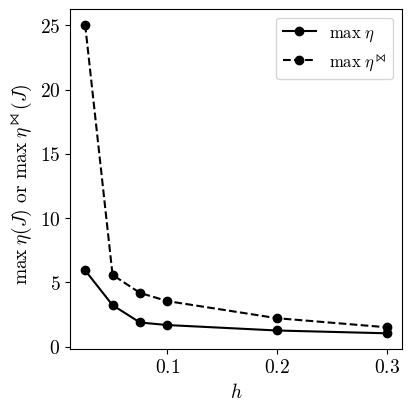

In [7]:
# compare max etaInf/ max eta across different h values

plt.figure(figsize=(4,4), constrained_layout=True)
h_values = [0.025,0.05, 0.075, 0.10, 0.2, 0.3]
max_eta_list = [max_eta_h025, max_eta_h050, max_eta_h075, max_eta_h100, max_eta_h200, max_eta_h300]
max_etaInf_list = [max_etaInf_h025, max_etaInf_h050, max_etaInf_h075, max_etaInf_h100, max_etaInf_h200, max_etaInf_h300]
plt.plot(h_values, max_eta_list, label=r'$\max\; \eta$', color='k', marker='o', linestyle='-', lw=1.5)
plt.plot(h_values, max_etaInf_list, label=r'$\max\; \eta^{\bowtie}$', color='k', marker='o', linestyle='--', lw=1.5)
plt.xlabel(r'$h$')
plt.ylabel(r'$\max\; \eta(J)$ or $\max\; \eta^{\bowtie}(J)$  ')
plt.legend();

## Finite size analysis

In [8]:
# load data
data100x100 = np.load('../data/aim_ness_100x100_h0.000.npz')
data200x100 = np.load('../data/aim_ness_200x100_h0.000.npz')
data200x200 = np.load('../data/aim_ness_200x200_h0.000.npz')
J_list = data100x100['J_list']

eta100x100, _, _ = compute_eta_first_principles(data100x100)
eta200x100, _, _ = compute_eta_first_principles(data200x100)
eta200x200, _, _ = compute_eta_first_principles(data200x200)

etaInf100x100, _, _ = compute_eta_inferential(data100x100)
etaInf200x100, _, _ = compute_eta_inferential(data200x100)
etaInf200x100, _, _ = compute_eta_inferential(data200x100)
etaInf200x200, _, _ = compute_eta_inferential(data200x200)

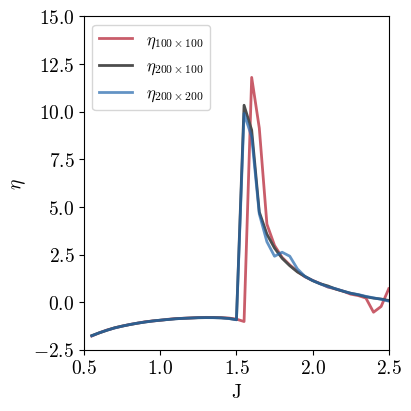

In [9]:
# plot eta comparison
plt.figure(figsize=(4,4), constrained_layout=True)

# Plot eta
plt.plot(J_list[1:], eta100x100, label=r'$\eta_{100 \times 100}$',color=COLORS[0], lw=2, alpha=0.7)
plt.plot(J_list[1:], eta200x100, label=r'$\eta_{200 \times 100}$',color=COLORS[2], lw=2, alpha=1.0)
plt.plot(J_list[1:], eta200x200, label=r'$\eta_{200 \times 200}$',color=COLORS[4], lw=2, alpha=0.7)
plt.xlabel('J');
plt.ylabel(r'$\eta$');
plt.xlim(0.5, 2.5);
plt.ylim(-2.5, 15);
plt.legend(loc='upper left');

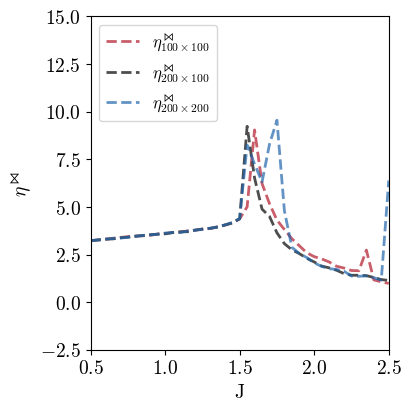

In [10]:
plt.figure(figsize=(4,4), constrained_layout=True)

# Plot etaInf
plt.plot(J_list, etaInf100x100, label=r'$\eta^{\bowtie}_{100 \times 100}$',color=COLORS[0], lw=2, alpha=0.7, linestyle='--')
plt.plot(J_list, etaInf200x100, label=r'$\eta^{\bowtie}_{200 \times 100}$',color=COLORS[2], lw=2, alpha=1.0, linestyle='--')
plt.plot(J_list, etaInf200x200, label=r'$\eta^{\bowtie}_{200 \times 200}$',color=COLORS[4], lw=2, alpha=0.7, linestyle='--')
plt.xlabel('J');
plt.ylabel(r'$\eta^{\bowtie}$');
plt.xlim(0.5, 2.5);
plt.ylim(-2.5, 15);
plt.legend(loc='upper left');